<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2024/01/Quantitative-Analysis-of-Stock-Market-using-Python.png?resize=1200%2C675&ssl=1"/>

In [1]:
## Stock Data

In [2]:
#!pip install yfinance pandas pyarrow

In [32]:
import yfinance as yf
import pandas as pd
import os
from datetime import datetime, timedelta
import threading
import time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [73]:
file="data/stock.parquet"
def up_to_date(ticker, interval="15m", lookback_days=60, filename=file):
    now = datetime.now() 
    
    # 1. File Exist
    if os.path.exists(file):
        master_df = pd.read_parquet(file)
        # Is data compatible
        if isinstance(master_df.columns, pd.MultiIndex):
            master_df.columns = master_df.columns.get_level_values(0)
    else:
        master_df = pd.DataFrame()

    # 2. Check date / time
    if not master_df.empty and 'Symbol' in master_df.columns:
        symbol_data = master_df[master_df['Symbol'] == ticker]
        if not symbol_data.empty:
            start_date = symbol_data.index.max()
        else:
            start_date = now - timedelta(days=lookback_days)
    else:
        start_date = now - timedelta(days=lookback_days)

    # 3. Get New Data
    # progress=False
    new_data = yf.download(ticker, start=start_date, interval=interval, progress=False)
    
    if new_data.empty:
        print(f"! {ticker} için yeni veri bulunamadı.")
        return master_df
 
    if isinstance(new_data.columns, pd.MultiIndex):
        new_data.columns = new_data.columns.get_level_values(0)
    
    #  Ticker ;
    new_data['Symbol'] = ticker

    # 4. Concat
    if master_df.empty:
        combined_df = new_data
    else:
        combined_df = pd.concat([master_df, new_data])

    # 5. Clean 
    combined_df.index.name = 'Datetime'
    combined_df = combined_df.reset_index()
    
    # Only New
    combined_df = combined_df.drop_duplicates(subset=['Datetime', 'Symbol'], keep='last')
    combined_df = combined_df.set_index('Datetime').sort_index()

    # 6. Save
    combined_df.to_parquet(filename, engine='pyarrow')
    
    print(f"✓ {ticker} updated. Number Of Rows : {len(combined_df)}")
    return combined_df


In [74]:
df=up_to_date("MSFT")

✓ MSFT updated. Number Of Rows : 1092


In [75]:
df=up_to_date("AAPL")

✓ AAPL updated. Number Of Rows : 2184


In [76]:
df=up_to_date("GOOG")

✓ GOOG updated. Number Of Rows : 3276


In [77]:
df=up_to_date("NFLX")

✓ NFLX updated. Number Of Rows : 4368


In [78]:
df=up_to_date("PYPL")

✓ PYPL updated. Number Of Rows : 5460


In [79]:
df=up_to_date("INTC")

✓ INTC updated. Number Of Rows : 6552


In [80]:
stocks_data=pd.read_parquet(file)

In [81]:
print(stocks_data.head())

Price                           Close        High         Low        Open  \
Datetime                                                                    
2026-02-03 14:30:00+00:00  416.184601  422.010010  415.600006  422.010010   
2026-02-03 14:30:00+00:00   81.995003   82.449997   81.320000   82.190002   
2026-02-03 14:30:00+00:00  344.929993  350.149994  343.597992  349.000000   
2026-02-03 14:30:00+00:00   50.000000   51.490002   49.935001   50.029999   
2026-02-03 14:30:00+00:00  268.209991  270.329987  267.690002  269.130005   

Price                        Volume Symbol  
Datetime                                    
2026-02-03 14:30:00+00:00   4197963   MSFT  
2026-02-03 14:30:00+00:00   3162979   NFLX  
2026-02-03 14:30:00+00:00   2050164   GOOG  
2026-02-03 14:30:00+00:00  12639843   INTC  
2026-02-03 14:30:00+00:00   3375803   AAPL  


In [82]:
descriptive_stats = stocks_data.groupby('Symbol')['Close'].describe()

In [83]:
pivot_data = stocks_data.pivot_table(index=stocks_data.index, columns='Symbol', values='Close')

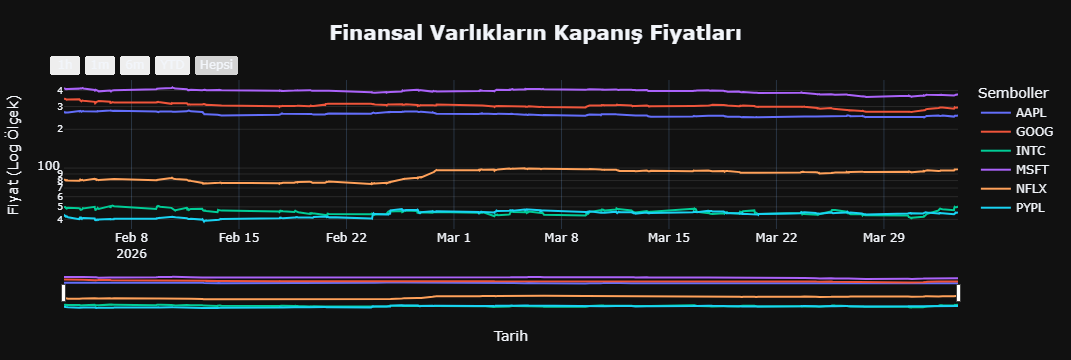

In [84]:
fig = make_subplots(rows=1, cols=1)

# Her sembol için çizgi (Trace) ekle
for column in pivot_data.columns:
    fig.add_trace(
        go.Scatter(
            x=pivot_data.index, 
            y=pivot_data[column], 
            name=column,
            mode='lines',
            line=dict(width=2), # Çizgi kalınlığı
            hovertemplate='%{x}<br>%{column}: %{y:.2f}' # Mouse ile üzerine gelince şık görünüm
        )
    )

# Düzeni Güncelle (Layout Customization)
fig.update_layout(
    title=dict(
        text='<b>Finansal Varlıkların Kapanış Fiyatları</b>',
        x=0.5,
        font=dict(size=20)
    ),
    template='plotly_dark', # Karanlık tema
    xaxis=dict(
        title='Tarih',
        rangeslider=dict(visible=True), # Alt tarafa kaydırma çubuğu
        rangeselector=dict(
            buttons=list([
                dict(count=7, label="1h", step="day", stepmode="backward"),
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(step="all", label="Hepsi")
            ])
        )
    ),
    yaxis=dict(
        title='Fiyat (Log Ölçek)',
        type='log', # Ölçek farklarını minimize eder
        gridcolor='rgba(255,255,255,0.1)'
    ),
    legend_title='Semboller',
    margin=dict(l=50, r=50, t=80, b=50),
    hovermode='x unified' # Aynı tarihteki tüm değerleri tek kutuda gösterir
)

fig.show()

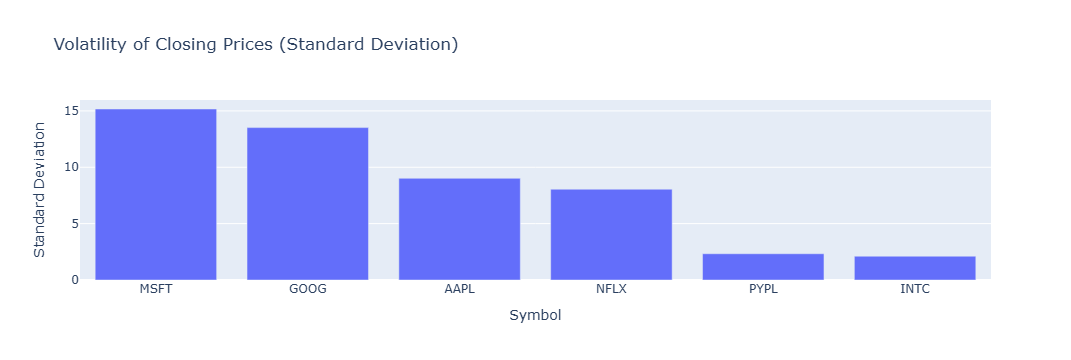

In [85]:
# Volatility Analysis
volatility = pivot_data.std().sort_values(ascending=False)

fig = px.bar(volatility,
             x=volatility.index,
             y=volatility.values,
             labels={'y': 'Standard Deviation', 'x': 'Symbol'},
             title='Volatility of Closing Prices (Standard Deviation)')

# Show the figure
fig.show()

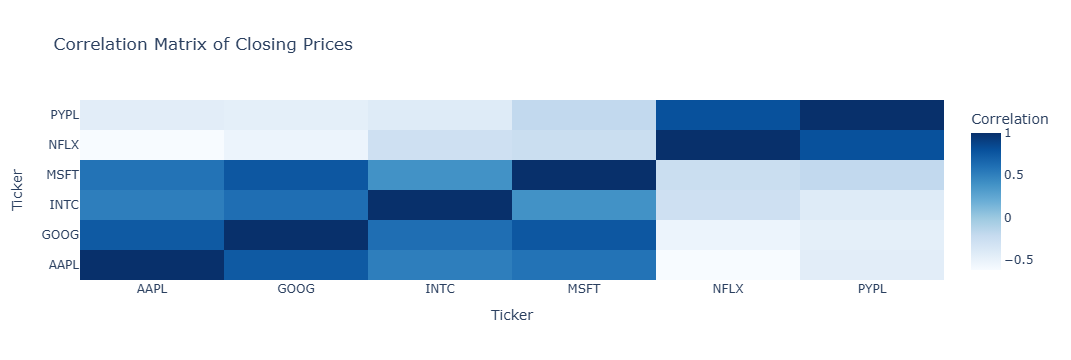

In [86]:
# Correlation Analysis
correlation_matrix = pivot_data.corr()

fig = go.Figure(data=go.Heatmap(
                    z=correlation_matrix,
                    x=correlation_matrix.columns,
                    y=correlation_matrix.columns,
                    colorscale='blues',
                    colorbar=dict(title='Correlation'),
                    ))

# Update layout
fig.update_layout(
    title='Correlation Matrix of Closing Prices',
    xaxis_title='Ticker',
    yaxis_title='Ticker'
)

# Show the figure
fig.show()

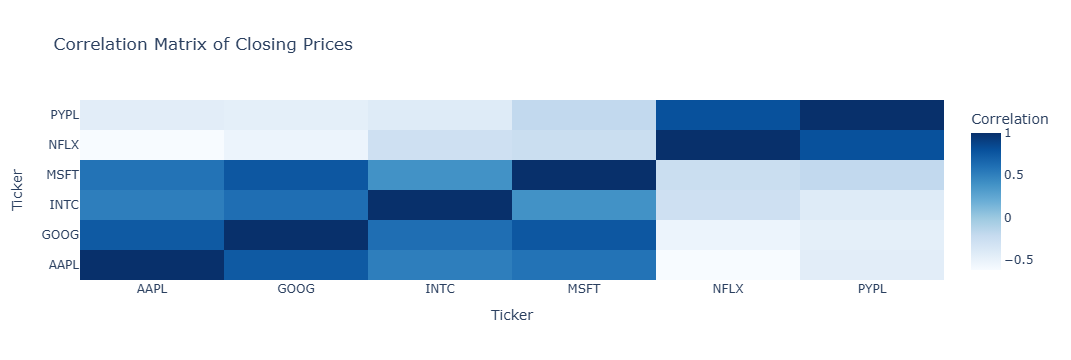

In [87]:
# Correlation Analysis
correlation_matrix = pivot_data.corr()

fig = go.Figure(data=go.Heatmap(
                    z=correlation_matrix,
                    x=correlation_matrix.columns,
                    y=correlation_matrix.columns,
                    colorscale='blues',
                    colorbar=dict(title='Correlation'),
                    ))

# Update layout
fig.update_layout(
    title='Correlation Matrix of Closing Prices',
    xaxis_title='Ticker',
    yaxis_title='Ticker'
)

# Show the figure
fig.show()

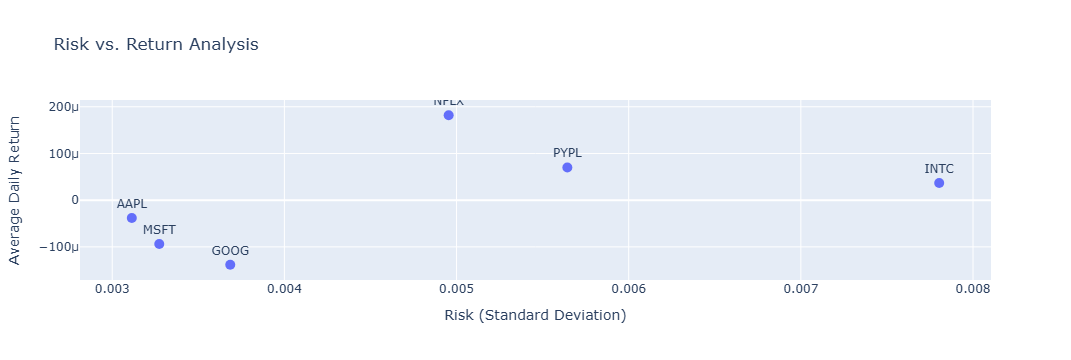

In [88]:
daily_returns = pivot_data.pct_change().dropna()

# Recalculating average daily return and standard deviation (risk)
avg_daily_return = daily_returns.mean()
risk = daily_returns.std()

# Creating a DataFrame for plotting
risk_return_df = pd.DataFrame({'Risk': risk, 'Average Daily Return': avg_daily_return})

fig = go.Figure()

# Add scatter plot points
fig.add_trace(go.Scatter(
    x=risk_return_df['Risk'],
    y=risk_return_df['Average Daily Return'],
    mode='markers+text',
    text=risk_return_df.index,
    textposition="top center",
    marker=dict(size=10)
))

# Update layout
fig.update_layout(
    title='Risk vs. Return Analysis',
    xaxis_title='Risk (Standard Deviation)',
    yaxis_title='Average Daily Return',
    showlegend=False
)

# Show the plot
fig.show()

## Risk Return Analysis 

## Summary